## EDA 3. Price Increase Threshold Modeling

#### 1. Overview
- There exists a price threshold beyond which churn risk accelerates non-linearly and substitution threat amplifies that tipping point 
- Price sensitivity differs structurally bt segment (Family vs Individual) and tenure cohort
- External substitution threat (Netflix alternative search intensity) acts as an amplifier that lowers the effective price threshold

#### 2. Research Hypothesis
- **Core Hypothesis**: Churn risk accelerates non-linearly beyond a price threshold, and this threshold is lowered when substitution threat is high
-**Sub Hypothesis**: Individual users reach their price threshold earlier than Family users use to higher per-capita cost burden 

#### 3. Key Inputs from H1 & H2
- H1: Segment X Price tier interaction confirms multiplicative churn risk (Fresh + High = 86.7%)
- H2: Family survivors show structurally lower churn sensitivity across all price tiers
- H3: Post-policy substitution search intensity increased +197% vs 76% for ad-free search --> substitution threat dominates



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [2]:
# Load data
df = pd.read_csv('../data/processed/cleaned_data.csv')
alt = pd.read_csv('../data/references/alternative_service_free_youtube.csv')

In [3]:
df.shape

(5534, 21)

In [4]:
print(df['Churn'].value_counts())

Churn
No     4063
Yes    1471
Name: count, dtype: int64


### 3.1. Data Preparation
Consistent filtering conditions from EDA 01 & 02
- calculated_tenure: reverse-engined from TotalCharges / MonthlyCharges
- Exclude July 2025 outlier (calculated_tenure == 7): confirmed as statistical noise in EDA 01
- Segment definition consistent with EDA 01 tenure cohorts

In [5]:

# Consistent processing from EDA 01 and EDA 02
df['calculated_tenure'] = (df['TotalCharges'] / df['MonthlyCharges']).round().fillna(0).astype(int)

# Exclude July 2025 outlier (Validated EDA 01)
df = df[df['calculated_tenure'] !=7]

# Tenure segments (consistent with EDA 01)
def categorize_tenure(t):
    if t >= 5: return 'Pre-Inflection (5mo+)'   # Before Sep 2025
    elif t >= 3: return 'Inflection (3-5mo)'    # Sep-Oct 2025 - Policy shock period
    else: return 'Fresh (<3mo)'                 # After Nov 2025

df['Segment'] = df['calculated_tenure'].apply(categorize_tenure)

# Price tier: qcut (equal size, consistent with EDA 01)
# Low: $18~$50 / Medium: $50~$84 / High: $84~$118
df['PriceTier'] = pd.qcut(df['MonthlyCharges'], q=3, labels=['Low', 'Medium', 'High'])

# Family vs Individual (consistent with EDA 02)
df['is_family'] = (df['Partner'] == 'Yes' )| (df['Dependents'] == 'Yes')
df['segment_type'] = df['is_family'].map({True: 'Family', False: 'Individual'})

print(f"Segment distribution:\n{df['Segment'].value_counts()}")
print(f"\nFamily vs Individual:\n{df['segment_type'].value_counts()}")

Segment distribution:
Segment
Pre-Inflection (5mo+)    4500
Fresh (<3mo)              639
Inflection (3-5mo)        297
Name: count, dtype: int64

Family vs Individual:
segment_type
Family        2921
Individual    2515
Name: count, dtype: int64


### 3.2. Price threshold Analyst

#### 3.2.1. Baseline: Natural Churn Rate
- Overall churn rate without price increase context
- Family vs Individual natural churn baseline

In [6]:
# Natural Churn Rate baseline (Full dataset, July excluded)
total = len(df)
churned = (df['Churn'] == 'Yes').sum()
natural_churn = churned / total * 100
print(f"Total Customers: {total}")
print(f"Churned Customers: {churned}")
print(f"Overall Churn Rate: {natural_churn:.2f}%")

# family_natural = df[df['is_family']]['Churn'].value_counts(normalize=True)['Yes'] * 100 --> if no Yes, this will error out
family_churn = df[df['is_family']]['Churn'].value_counts(normalize=True).get('Yes', 0) * 100    # if no Yes, default to 0%
individual_churn = df[~df['is_family']]['Churn'].value_counts(normalize=True).get('Yes', 0) * 100

print(f"Family Churn Rate: {family_churn:.2f}%")
print(f"Individual Churn Rate: {individual_churn:.2f}%")

Total Customers: 5436
Churned Customers: 1430
Overall Churn Rate: 26.31%
Family Churn Rate: 19.82%
Individual Churn Rate: 33.84%


#### 3.2.2. Churn Rate by Segment X Proce Tier X Family/Individual
- Extends EDA 01 analysis by adding Family/Individual dimension
- **NOTE**: Inflection(3-5 mo) segment represents policy shock response, not pure price sensitivity
  - These customers joined Sep - Oct 2025, experienced policy change immediately
  - Their churn reflects policy betrayal effect, not price threshold behavior

In [7]:
# Churn Rate by Segment X Price Tier X Family/Individual
churn_rates = df.groupby(['Segment', 'PriceTier', 'segment_type'], observed=True)['Churn'].value_counts(normalize=True).unstack(fill_value=0)['Yes'] * 100

print("\nChurn Rates by Segment, Price Tier, and Family/Individual:")
print(churn_rates)



Churn Rates by Segment, Price Tier, and Family/Individual:
Segment                PriceTier  segment_type
Fresh (<3mo)           Low        Family          46.052632
                                  Individual      43.495935
                       Medium     Family          63.157895
                                  Individual      75.124378
                       High       Family          83.333333
                                  Individual      87.804878
Inflection (3-5mo)     Low        Family          25.531915
                                  Individual      36.708861
                       Medium     Family          62.857143
                                  Individual      50.588235
                       High       Family          87.500000
                                  Individual      62.857143
Pre-Inflection (5mo+)  Low        Family           6.557377
                                  Individual      11.033275
                       Medium     Family          16.

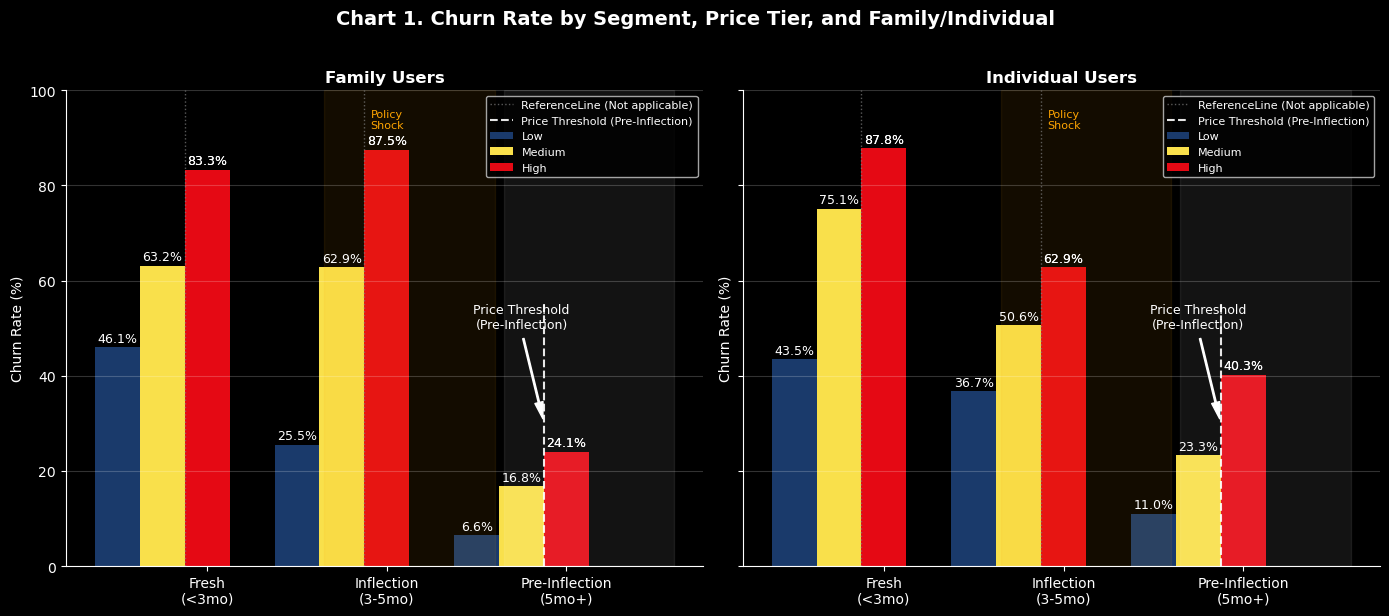

In [8]:
# Visualization - Grouped Bar Chart
plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
fig.suptitle('Chart 1. Churn Rate by Segment, Price Tier, and Family/Individual', fontsize=14, fontweight='bold', y=1.02)
segment_order = ['Fresh (<3mo)', 'Inflection (3-5mo)', 'Pre-Inflection (5mo+)']
price_tiers = ['Low', 'Medium', 'High']
colors = {'Low': '#1a3a6b', 'Medium': '#f9e04b', 'High': '#e50914'}

x = np.arange(len(segment_order))
width = 0.25

for idx, seg_type in enumerate(['Family', 'Individual']):
    for i, price in enumerate(price_tiers):
        vals = [churn_rates.get((seg, price, seg_type), 0) 
                for seg in segment_order]
        bars = axes[idx].bar(x + (i - 1) * width, vals, width, label=price, color=colors[price])
    
        # Value labels on bars
        for bar in bars:
            height = bar.get_height()
            axes[idx].text(bar.get_x() + bar.get_width() / 2, height + 0.5, f'{height:.1f}%', 
                           ha='center', va='bottom', fontsize=9, color='white')

    # Value labels on bars
    for bar in bars:
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width() / 2, height + 0.5, f'{height:.1f}%', 
                       ha='center', va='bottom', fontsize=9, color='white')
        
    # Threshold and Reference Lines
    for seg_idx in range(3):
        threshold_x = x[seg_idx] + 0.5 * width   # Position threshold line between Medium and High

        if seg_idx ==2:  # Pre-Inflection segment
            axes[idx].plot([threshold_x, threshold_x], [0, 55], color='white', linestyle='--', linewidth=1.5, alpha=0.9,label='Price Threshold (Pre-Inflection)')

            # Annotation on Medium bar with arrow pointing --> to threshold line
            text_x = threshold_x - 0.5 * width
            axes[idx].annotate('Price Threshold\n(Pre-Inflection)', xy=(threshold_x, 30), xytext=(text_x, 50),
                        arrowprops=dict(facecolor='white', shrink=0.05, width=1, headwidth=6), fontsize=9, color='white', ha='center')
        
        else:   # For Fresh and Inflection segments: grey dotted (Reference Only)
            axes[idx].plot([threshold_x, threshold_x], [0, 100], color='grey', linestyle=':', linewidth=1, alpha=0.7, label='ReferenceLine (Not applicable)' if seg_idx==0 else '' )


    # Zone Highlighting
    # Pre-Inflection: Highlight High Price Tier zone (above threshold) with red shade
    axes[idx].axvspan(x[2] - 0.1, x[2] + 3*width + 0.1, alpha=0.08, color='white')

    # Infection zone:policy shock label
    axes[idx].axvspan(x[1] - 0.1, x[1] + 3*width + 0.1, alpha=0.08, color='orange')
    axes[idx].text(x[1] + width, 92, 'Policy\nShock',
            ha='center', color='orange', fontsize=8)
    
    # Axes formatting
    axes[idx].set_title(f"{seg_type} Users", fontsize=12, fontweight='bold')
    axes[idx].set_xticks(x + width)
    axes[idx].set_xticklabels(['Fresh\n(<3mo)', 'Inflection\n(3-5mo)', 'Pre-Inflection\n(5mo+)'], fontsize=10)
    axes[idx].set_ylabel('Churn Rate (%)', fontsize=10)
    axes[idx].set_ylim(0, 100)
    axes[idx].legend(fontsize=8, title_fontsize=9, loc='upper right')
    axes[idx].grid(axis='y', alpha=0.2)
    axes[idx].spines['top'].set_visible(False)
    axes[idx].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/eda_03/graph1_grouped_bar.png', dpi=150, bbox_inches='tight')
plt.show()


#### 3.2.3. Price Threshold: Pre-Inflection Segment (Core Analysis)
- Focus-on Pre-Inflection (5 mo+): long-term customers who experienced price increase
- Inflection segment excluded from threshold analysis (policy shock effect, not price sensitivity)
- This is the cleanest signal for price resistance


In [9]:
# Focus on Pre-Inflection Segment: Pure price sensitivity
pre_inflection = df[df['Segment'] == 'Pre-Inflection (5mo+)'].copy()

# Finer price granularity to find exact threshold
bins_fine = [0, 35, 55, 75, 95, 120]
labels_fine = ['0-35', '35-55', '55-75', '75-95', '95-120']
pre_inflection['PriceTierFine'] = pd.cut(pre_inflection['MonthlyCharges'], bins=bins_fine, labels=labels_fine, include_lowest=True)
threshold_result = pre_inflection.groupby('PriceTierFine', observed=True)['Churn'].value_counts(normalize=True).unstack(fill_value=0)['Yes'] * 100

print("\nPre-Inflection Segment Churn Rates by Finer Price Tiers:")
print(threshold_result)

# Calculate confidence intervals for each price tier
ci_results = {}
for tier in labels_fine:
    tier_data = pre_inflection[pre_inflection['PriceTierFine'] == tier]
    churned = (tier_data['Churn'] == 'Yes').sum()
    total = len(tier_data)
    if total > 0:
        churn_rate = churned / total
        ci_low, ci_upp = stats.binom.interval(0.95, total, churn_rate, loc=0)
        ci_results[tier] = (churn_rate * 100, ci_low / total * 100, ci_upp / total * 100)
    else:
        ci_results[tier] = (0, 0, 0)  # No data for this tier


# Calculate change between tiers
print("\nChurn Rate Changes Between Price Tiers (Pre-Inflection Segment):")
vals = threshold_result.values
for i in range(1, len(vals)):
    change = vals[i] - vals[i-1]
    print(f'  {labels_fine[i-1]} → {labels_fine[i]}: {change:+.1f}%p')



Pre-Inflection Segment Churn Rates by Finer Price Tiers:
PriceTierFine
0-35       5.640535
35-55     16.194332
55-75     17.218543
75-95     27.257800
95-120    31.104357
Name: Yes, dtype: float64

Churn Rate Changes Between Price Tiers (Pre-Inflection Segment):
  0-35 → 35-55: +10.6%p
  35-55 → 55-75: +1.0%p
  55-75 → 75-95: +10.0%p
  75-95 → 95-120: +3.8%p


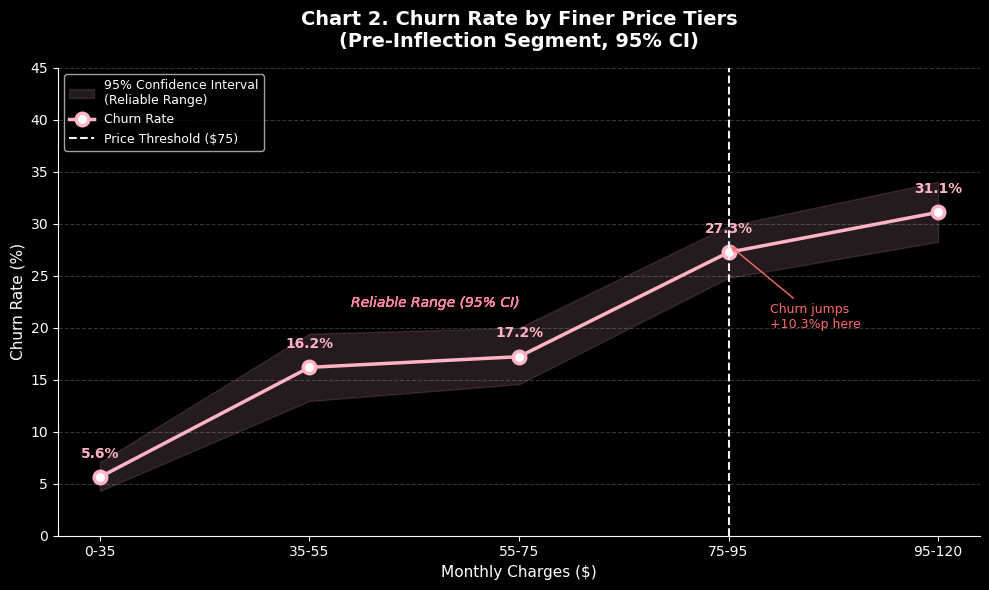

In [10]:
# Visualization - Line Chart with Confidence Intervals
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 6))

# Prepare data from ci_results
tiers = list(ci_results.keys())
churn_rates_line = [ci_results[t][0] for t in tiers]
ci_lows = [ci_results[t][1] for t in tiers]
ci_upps = [ci_results[t][2] for t in tiers]

# Confidence interval band
ax.fill_between(tiers, ci_lows, ci_upps,
                color='#FFB3C6',
                alpha=0.15,
                label='95% Confidence Interval\n(Reliable Range)')

# Main line
ax.plot(tiers, churn_rates_line,
        marker='o',
        color='#FFB3C6',
        linewidth=2.5,
        markersize=9,
        markerfacecolor='white',
        markeredgewidth=2.5,
        label='Churn Rate')

# Annotate each data point
for i, (tier, rate) in enumerate(zip(tiers, churn_rates_line)):
    ax.annotate(f'{rate:.1f}%',
                xy=(i, rate),
                xytext=(0, 14),
                textcoords='offset points',
                ha='center',
                fontsize=10,
                fontweight='bold',
                color='#FFB3C6')
    
    ax.annotate('Reliable Range (95% CI)',
            xy=(1, ci_upps[1]),
            xytext=(1.2, 22),
            fontsize=10,
            color='#FF85A1',
            style='italic')

# Price threshold line
ax.axvline(x='75-95',
           color='#F5F5F5',
           linestyle='--',
           linewidth=1.5,
           label='Price Threshold ($75)')

# Threshold annotation
ax.annotate('Churn jumps\n+10.3%p here',
            xy=(3, 28),
            xytext=(3.2, 20),
            fontsize=9,
            color='#FF6B6B',
            arrowprops=dict(arrowstyle='->', color='#FF6B6B'))

# Styling
ax.set_title('Chart 2. Churn Rate by Finer Price Tiers\n(Pre-Inflection Segment, 95% CI)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Monthly Charges ($)', fontsize=11)
ax.set_ylabel('Churn Rate (%)', fontsize=11)
ax.set_ylim(0, 45)  # Tighter y-axis
ax.legend(loc='upper left', fontsize=9)
ax.grid(axis='y', alpha=0.2, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/eda_03/graph2_line_chart.png', dpi=150, bbox_inches='tight')
plt.show()

#### 3.3. Substitution Threat as Amplifier

##### Search Intensity: Netflix Alternative vs Ad-Free YouTube
- Post-policy substitution search increased + 115% vs +68.3% for ad-free search
- substitution threat grows 1.7x faster than ad-aversion utility
- This amplifies price sensitivity - lowers effective threshold


In [11]:
# Substitution threat analysis: Compare with alternative service (YouTube Free)
# Convert Time column to datetime
alt['Time'] = pd.to_datetime(alt['Time'])

# Remove July outlier FIRST before calculation
alt = alt[alt['Time'].dt.month != 7]

# Verify
print(f'Data after removing July: {len(alt)} rows')
pre_policy = alt[alt['Time'] < '2025-09-01']
post_policy = alt[alt['Time'] >= '2025-09-01']

netflix_pre = pre_policy['netflix alternative'].mean()
netflix_post = post_policy['netflix alternative'].mean()
adfree_pre = pre_policy['ad free youtube'].mean()
adfree_post = post_policy['ad free youtube'].mean()

netflix_change = (netflix_post - netflix_pre) / netflix_pre * 100
adfree_change = (adfree_post - adfree_pre) / adfree_pre * 100

print('*** Substitution Threat Analysis (YouTube Free) ***')
print(f'Netflix Alternative: {netflix_pre:.1f} -> {netflix_post:.1f} ({netflix_change:+.1f}%)')
print(f'Ad-Free YouTube: {adfree_pre:.1f} → {adfree_post:.1f} ({adfree_change:+.1f}%)')
print(f'\nSubstitution grows {netflix_change / adfree_change:.1f} X faster than ad-aversion')
print(f'\n -> Substitution threat dominates as churn amplifier post price increase')


Data after removing July: 24 rows
*** Substitution Threat Analysis (YouTube Free) ***
Netflix Alternative: 11.4 -> 34.0 (+197.1%)
Ad-Free YouTube: 29.8 → 52.5 (+76.3%)

Substitution grows 2.6 X faster than ad-aversion

 -> Substitution threat dominates as churn amplifier post price increase


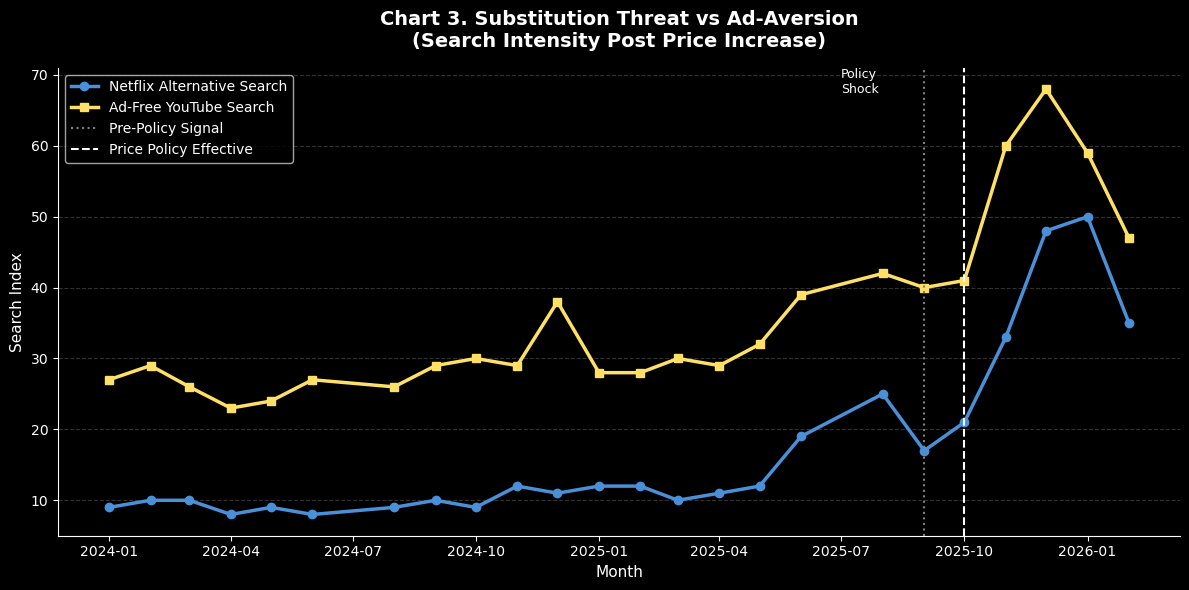

In [12]:


fig, ax = plt.subplots(figsize=(12, 6))

# Plot dual lines
ax.plot(alt['Time'], alt['netflix alternative'],
        marker='o', linewidth=2.5,
        color='#4A90D9',  # Netflix - Soft Yellow
        markersize=6,
        label='Netflix Alternative Search')

ax.plot(alt['Time'], alt['ad free youtube'],
        marker='s', linewidth=2.5,
        color='#FFE066',  # YouTube - Soft Green
        markersize=6,
        label='Ad-Free YouTube Search')

# Policy change vertical line
ax.axvline(x=pd.Timestamp('2025-09-01'), 
           color='gray', linestyle=':', label='Pre-Policy Signal')
ax.axvline(x=pd.Timestamp('2025-10-01'), 
           color='white', linestyle='--', label='Price Policy Effective')

# Annotation
ax.annotate('Policy\nShock',
            xy=(pd.Timestamp('2025-09-01'), ax.get_ylim()[1]*0.9),
            xytext=(pd.Timestamp('2025-07-01'), ax.get_ylim()[1]*0.95),
            fontsize=9, color='white')

# Styling
ax.set_title('Chart 3. Substitution Threat vs Ad-Aversion\n(Search Intensity Post Price Increase)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Search Index', fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.2, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/eda_03/graph3_dual_line.png', dpi=150, bbox_inches='tight')
plt.show()

#### 3.4. Price Scenario Simulation

##### Mapping to YouTube Premium
- Current YouTube Premium: Individual $13.99 / Family $22.99
- Pre-Infection segment identified as core stable user base
- Price threshold identifies at $75+ tier (H3 confirmed)
- Simulation based on % increase scenarios
- Individual churn risk threated as separate risk factor

##### NOTE (Proxy Data Limitation)
- Sensitivity direction is validated (Individual > Family)
- Absoulte values are directional only, not precise
- Results should be interpreted as relative comparison, not absolute prediction

In [13]:
# Base prices (pre-tax)
base_individual = 13.99
base_family = 22.99

# Price increase scenarios
scenarios = [0.05, 0.10, 0.17, 0.28]

# Pre-Infection segment
pre_inf = df[df['Segment'] == 'Pre-Inflection (5mo+)'].copy()

# Baseline churn rates (Pre-Inflection segment)
pre_inflection_churn = df[df['Segment'] == 'Pre-Inflection (5mo+)'].groupby('segment_type')['Churn']\
    .value_counts(normalize=True).unstack(fill_value=0)['Yes']  * 100

print("\nBaseline Churn Rates (Pre-Inflection Segment):")
print(pre_inflection_churn)

family_churn = pre_inflection_churn.get('Family', 0)
individual_churn = pre_inflection_churn.get('Individual', 0)

print(f"\nBaseline Churn Rate (Family): {family_churn:.2f}%")
print(f"Baseline Churn Rate (Individual): {individual_churn:.2f}%")



Baseline Churn Rates (Pre-Inflection Segment):
segment_type
Family        16.654192
Individual    25.328228
Name: Yes, dtype: float64

Baseline Churn Rate (Family): 16.65%
Baseline Churn Rate (Individual): 25.33%


In [14]:
# Customer Proportion (ratio-based)
family_customers = len(pre_inf[pre_inf['segment_type'] == 'Family'])
individual_customers = len(pre_inf[pre_inf['segment_type'] == 'Individual'])
total_customers = family_customers + individual_customers

family_prop = family_customers / total_customers
individual_prop = individual_customers / total_customers

print(f"Family Customers: {family_customers} ({family_prop:.1%})")
print(f"Individual Customers: {individual_customers} ({1-family_prop:.1%})")
print(f"\nTotal Customers (Pre-Inflection): {total_customers}")


Family Customers: 2672 (59.4%)
Individual Customers: 1828 (40.6%)

Total Customers (Pre-Inflection): 4500


In [15]:
# Validation 1. Price Elasticity Check: 
# changes across price tiers in the Pre-Inflection segment 
# The sharp increase in churn above the $75 threshold supports the higher sensitivity for Individual customers, 
# while the more gradual increase for Family customers justifies the lower sensitivity.

# Auto-calculate midpoints from bins
price_midpoints = [(bins_fine[i] + bins_fine[i+1]) / 2 for i in range(len(bins_fine)-1)]

# Store results
elasticity_results = {}
elasticity_threshold = {}

pre_inf['PriceTierFine'] = pd.cut(
    pre_inf['MonthlyCharges'],
    bins=bins_fine,
    labels=labels_fine,
    include_lowest=True
)

print('*** Price Elasticity by Tier ***')

for seg in ['Family', 'Individual']:
    print(f'\n*** {seg} ***')
    seg_data = pre_inf[pre_inf['segment_type'] == seg].copy()

    # Churn rates by price tier
    seg_churn = seg_data.groupby('PriceTierFine', observed=True)['Churn']\
        .value_counts(normalize=True)\
        .unstack(fill_value=0)['Yes'] * 100
    
    churn_rates_seg = [seg_churn.loc[tier] if tier in seg_churn.index else 0 for tier in labels_fine]


    elasticities = []

    for i in range (1, len(labels_fine)):
        price_change_pct = (price_midpoints[i] - price_midpoints[i-1]) / price_midpoints[i-1] * 100
        churn_change = churn_rates_seg[i] - churn_rates_seg[i-1]
        elasticity = churn_change / price_change_pct if price_change_pct != 0 else 0
        elasticities.append(elasticity)
        
        print(f'{labels_fine[i-1]} --> {labels_fine[i]}: '
            f'Price Change = {price_change_pct:.2f}%, '
            f' Churn Change = {churn_change:.2f}%, '
            f'Elasticity = {elasticity:.4f}') 


    avg_elasticity = sum(elasticities) / len(elasticities)
    elasticity_results[seg] = avg_elasticity
    elasticity_threshold[seg] = elasticities[2]  # Elasticity at $75 threshold (3rd tier change)


    print(f'\n{seg} Average Elasticity: {avg_elasticity:.4f}')
    print(f'{seg} Threshold Elasticity ($75): {elasticities[2]:.4f}')


print(f'\nAverage Elasticity across tiers: {avg_elasticity:.4f}')


*** Price Elasticity by Tier ***

*** Family ***
0-35 --> 35-55: Price Change = 157.14%,  Churn Change = 8.91%, Elasticity = 0.0567
35-55 --> 55-75: Price Change = 44.44%,  Churn Change = 0.59%, Elasticity = 0.0133
55-75 --> 75-95: Price Change = 30.77%,  Churn Change = 8.11%, Elasticity = 0.2635
75-95 --> 95-120: Price Change = 26.47%,  Churn Change = 3.16%, Elasticity = 0.1196

Family Average Elasticity: 0.1133
Family Threshold Elasticity ($75): 0.2635

*** Individual ***
0-35 --> 35-55: Price Change = 157.14%,  Churn Change = 11.74%, Elasticity = 0.0747
35-55 --> 55-75: Price Change = 44.44%,  Churn Change = 2.27%, Elasticity = 0.0510
55-75 --> 75-95: Price Change = 30.77%,  Churn Change = 13.56%, Elasticity = 0.4407
75-95 --> 95-120: Price Change = 26.47%,  Churn Change = 6.46%, Elasticity = 0.2439

Individual Average Elasticity: 0.2026
Individual Threshold Elasticity ($75): 0.4407

Average Elasticity across tiers: 0.2026


In [16]:
# Validation 2. Logistic Regression Check: We can run a logistic regression on the Pre-Inflection segment to see 
# if the price tier and segment type are significant predictors of churn, and if the coefficients align with our sensitivity assumptions

regression_results = {}

# Dynamic Sensitivity Function: This function can be used in the simulation to adjust sensitivity based on the price increase rate
def get_dynamic_sensitivity(rate, seg):
    avg = elasticity_results[seg]
    threshold = elasticity_threshold[seg]
    mid = (avg + threshold) / 2
    if rate <= 0.10:
        return avg
    elif rate <= 0.17:
        return mid
    else:
        return threshold


print('\n*** Logistic Regression Coefficients ***')
for seg in ['Family', 'Individual']:
    seg_data = pre_inf[pre_inf['segment_type'] == seg].copy()

    x = seg_data[['MonthlyCharges']]
    y = (seg_data['Churn'] == 'Yes').astype(int)

    # Scale features
    scalar = StandardScaler()
    x_scaled = scalar.fit_transform(x)

    # Fit Model
    model = LogisticRegression(random_state=42)
    model.fit(x_scaled, y)

    # Convert coefficient back to original scale
    coef_original = model.coef_[0][0] / scalar.scale_[0]
    regression_results[seg] = coef_original
    odds_ratio = np.exp(coef_original)

    print(f'\nSegment: {seg}')
    print(f'Coefficient for MonthlyCharges: {coef_original:.4f}')
    print(f'Odds Ratio: {odds_ratio:.4f} {coef_original:.4f} ($1 increase)')




*** Logistic Regression Coefficients ***

Segment: Family
Coefficient for MonthlyCharges: 0.0204
Odds Ratio: 1.0207 0.0204 ($1 increase)

Segment: Individual
Coefficient for MonthlyCharges: 0.0258
Odds Ratio: 1.0261 0.0258 ($1 increase)


In [17]:
# Sensitive Summary Validation
# Compare & Confirm Sensitivity: The coefficients from the logistic regression should reflect the relative sensitivity 
# of churn to price changes for Family vs Individual segments

print('\n\n*** Sensitivity Validation Summary ***')
print(f'\n{"Method":<25} {"Family":<15} {"Individual"}')
print('-' * 50)

print(f'{"Price Elasticity":<25} {elasticity_results["Family"]:<15.3f} {elasticity_results["Individual"]:.3f}')
print(f'{"Logistic Regression":<25} {regression_results["Family"]*100:<15.3f} {regression_results["Individual"]*100:.3f}')

print('\n --> If results are similar = sensitivity values confirmed ✔️')
print('--> If results differ = adjust sensitivity values ❕')



*** Sensitivity Validation Summary ***

Method                    Family          Individual
--------------------------------------------------
Price Elasticity          0.113           0.203
Logistic Regression       2.044           2.580

 --> If results are similar = sensitivity values confirmed ✔️
--> If results differ = adjust sensitivity values ❕


In [18]:
# Price Scenario Simulation

results_all = []

for rate in scenarios:
    print(f'\n*** Simulating Price Increase: {rate*100:.0f}% ***')
    dynamic_f_sens = get_dynamic_sensitivity(rate, 'Family')
    dynamic_i_sens = get_dynamic_sensitivity(rate, 'Individual')

    print(f'\n+{int(rate*100)}% Scenario')
    print(f'Applied Sensitivity - Family: {dynamic_f_sens:.3f}, Individual: {dynamic_i_sens:.3f}')


    new_f_price = base_family * (1 + rate)
    new_i_price = base_individual * (1 + rate)

    f_churn_new = family_churn * (1 + dynamic_f_sens * rate)
    i_churn_new = individual_churn * (1 + dynamic_i_sens * rate)

    family_retained = family_prop * ( 1- f_churn_new / 100)
    individual_retained = individual_prop * (1 - i_churn_new / 100)

    family_rev = family_retained * new_f_price
    individual_rev = individual_retained * new_i_price
    total_rev = family_rev + individual_rev

    individual_lost = (individual_prop - individual_retained) * new_i_price
    
    results_all.append({
        'Price Increase':     f'+{int(rate*100)}%',
        'Family Price':       round(new_f_price, 2),
        'Ind Price':          round(new_i_price, 2),
        'Family Churn':       round(f_churn_new, 2),
        'Ind Churn':          round(i_churn_new, 2),
        'Family Rev Index':   round(family_rev, 4),
        'Ind Risk Index':     round(individual_lost, 4),
        'Total Rev Index':    round(total_rev, 4)
    })

    results_df = pd.DataFrame(results_all)
    print(results_df.to_string(index=False))





*** Simulating Price Increase: 5% ***

+5% Scenario
Applied Sensitivity - Family: 0.113, Individual: 0.203
Price Increase  Family Price  Ind Price  Family Churn  Ind Churn  Family Rev Index  Ind Risk Index  Total Rev Index
           +5%         24.14      14.69         16.75      25.58           11.9329          1.5267          16.3734

*** Simulating Price Increase: 10% ***

+10% Scenario
Applied Sensitivity - Family: 0.113, Individual: 0.203
Price Increase  Family Price  Ind Price  Family Churn  Ind Churn  Family Rev Index  Ind Risk Index  Total Rev Index
           +5%         24.14      14.69         16.75      25.58           11.9329          1.5267          16.3734
          +10%         25.29      15.39         16.84      25.84           12.4869          1.6154          17.1228

*** Simulating Price Increase: 17% ***

+17% Scenario
Applied Sensitivity - Family: 0.188, Individual: 0.322
Price Increase  Family Price  Ind Price  Family Churn  Ind Churn  Family Rev Index  Ind Risk

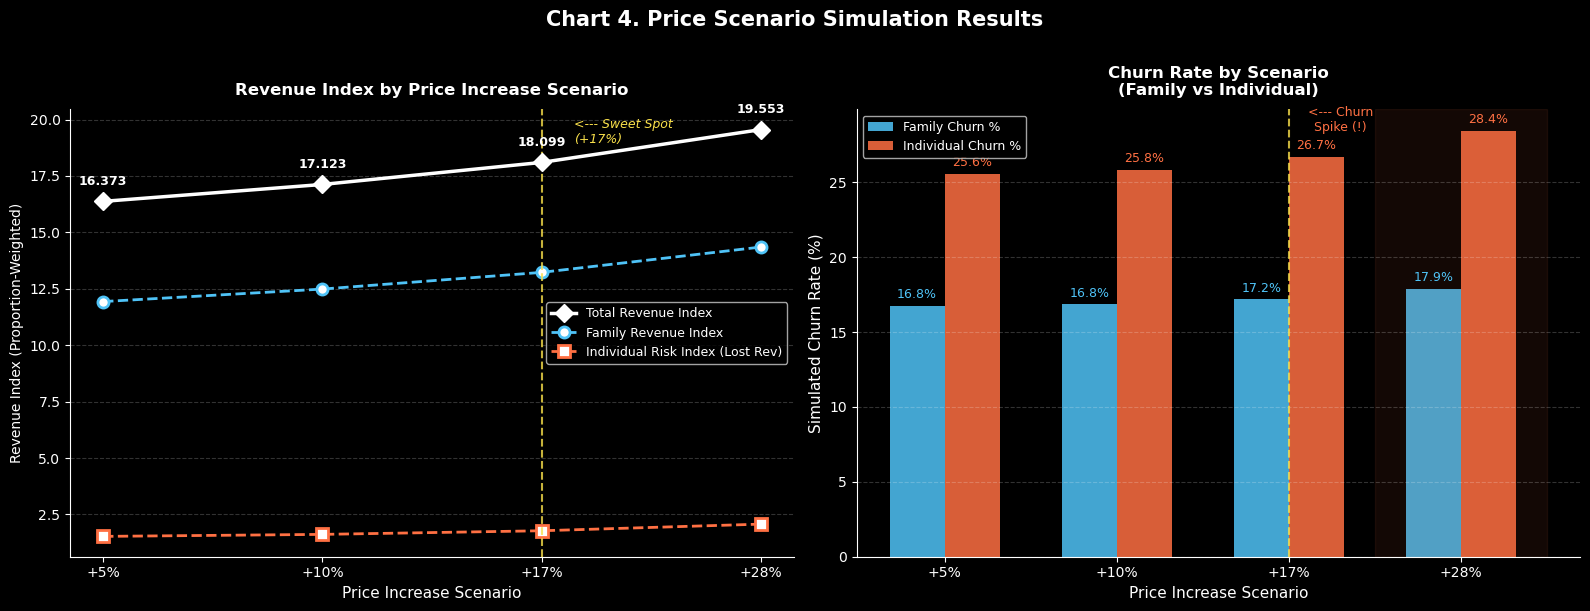

In [19]:
# Chart 4: Price Scenario Simulation Results — Dual Panel
plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Chart 4. Price Scenario Simulation Results', fontsize=15, fontweight='bold', y=1.01)

scenarios_labels = [r['Price Increase'] for r in results_all]
family_rev       = [r['Family Rev Index'] for r in results_all]
ind_risk         = [r['Ind Risk Index'] for r in results_all]
total_rev        = [r['Total Rev Index'] for r in results_all]
family_churn_sim = [r['Family Churn'] for r in results_all]
ind_churn_sim    = [r['Ind Churn'] for r in results_all]

x = np.arange(len(scenarios_labels))

# LEFT PANEL: Revenue Index 
ax1 = axes[0]

ax1.plot(scenarios_labels, total_rev,
         marker='D', linewidth=2.5, markersize=9,
         color='#FFFFFF', markerfacecolor='white',
         label='Total Revenue Index', zorder=5)
ax1.plot(scenarios_labels, family_rev,
         marker='o', linewidth=2, markersize=8,
         color='#4FC3F7', markerfacecolor='white', markeredgewidth=2,
         label='Family Revenue Index', linestyle='--')
ax1.plot(scenarios_labels, ind_risk,
         marker='s', linewidth=2, markersize=8,
         color='#FF7043', markerfacecolor='white', markeredgewidth=2,
         label='Individual Risk Index (Lost Rev)', linestyle='--')

# Annotate Total Rev values
for i, (lbl, val) in enumerate(zip(scenarios_labels, total_rev)):
    ax1.annotate(f'{val:.3f}',
                 xy=(i, val), xytext=(0, 12),
                 textcoords='offset points',
                 ha='center', fontsize=9, fontweight='bold', color='white')

# Sweet spot highlight at +17%
sweet_idx = scenarios_labels.index('+17%')
ax1.axvline(x=sweet_idx, color='#F9E04B', linestyle='--', linewidth=1.5, alpha=0.8)
ax1.annotate('<--- Sweet Spot\n(+17%)',
             xy=(sweet_idx, max(total_rev) * 0.97),
             xytext=(sweet_idx + 0.15, max(total_rev) * 0.97),
             fontsize=9, color='#F9E04B', fontstyle='italic')

ax1.set_title('Revenue Index by Price Increase Scenario', fontsize=12, fontweight='bold', pad=10)
ax1.set_xlabel('Price Increase Scenario', fontsize=11)
ax1.set_ylabel('Revenue Index (Proportion-Weighted)', fontsize=10)
ax1.legend(fontsize=9, loc='center right')
ax1.grid(axis='y', alpha=0.2, linestyle='--')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# RIGHT PANEL: Churn Rate 
ax2 = axes[1]
width = 0.32

bars_f = ax2.bar(x - width/2, family_churn_sim, width,
                 label='Family Churn %', color='#4FC3F7', alpha=0.85)
bars_i = ax2.bar(x + width/2, ind_churn_sim,    width,
                 label='Individual Churn %', color='#FF7043', alpha=0.85)

# Value labels on bars
for bar in bars_f:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h + 0.3,
             f'{h:.1f}%', ha='center', va='bottom', fontsize=9, color='#4FC3F7')
for bar in bars_i:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h + 0.3,
             f'{h:.1f}%', ha='center', va='bottom', fontsize=9, color='#FF7043')

# Warning zone: +28% Individual churn spike
ax2.axvspan(2.5, 3.5, alpha=0.08, color='#FF7043')
ax2.text(2.3, max(ind_churn_sim) * 1.0, '<--- Churn\nSpike (!)',
         ha='center', color='#FF7043', fontsize=9)

# Sweet spot line
ax2.axvline(x=sweet_idx, color='#F9E04B', linestyle='--', linewidth=1.5, alpha=0.8)

ax2.set_title('Churn Rate by Scenario\n(Family vs Individual)', fontsize=12, fontweight='bold', pad=10)
ax2.set_xlabel('Price Increase Scenario', fontsize=11)
ax2.set_ylabel('Simulated Churn Rate (%)', fontsize=11)
ax2.set_xticks(x)
ax2.set_xticklabels(scenarios_labels, fontsize=10)
ax2.legend(fontsize=9, loc='upper left')
ax2.grid(axis='y', alpha=0.2, linestyle='--')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/eda_03/graph4_simulation_dual.png', dpi=150, bbox_inches='tight')
plt.show()

#### 3.5. Statistical Validation

##### Chi-Square Test: Price Tier X Churn Independence
-  Test whether churn rate difference across price tiers is statistically significant
- Focus: Pre-Inflection Individual segment (cleanest price signal)

In [20]:
from scipy.stats import chi2_contingency

print('*** Chi-Square Statistical Validation ***')

# Test 1. Churn vs PriceTierFine (Pre-Inflection)
cont_price = pd.crosstab(pre_inflection['PriceTierFine'],
                         pre_inflection['Churn'])

chi2_price, p_price, dof_price, _ = chi2_contingency(cont_price)

print('\n*** Churn vs Price Tier (Pre-Inflection Segment)')
print(cont_price)
print(f'\nChi2: {chi2_price:.4f} | p-value: {p_price:.4f} | dof: {dof_price}')

if p_price < 0.05:
    print('Significant: churn rate differs across price tiers!')
else:
    print('NOT SIGNIFICANT!!')

# Test 2. Churn vs Segment Type (Family vs Individual)
cont_seg = pd.crosstab(pre_inflection['segment_type'],
                        pre_inflection['Churn'])

chi2_seg, p_seg, dof_seg, _ = chi2_contingency(cont_seg)

print('\n*** Churn vs Segment Type (Family vs Individual)')
print(cont_seg)
print(f'\nChi2: {chi2_seg:.4f} | p-value: {p_seg:.4f} | dof: {dof_seg}')

if p_price < 0.05:
    print('Significant: Family and Individual churn differs!')
else:
    print('NOT SIGNIFICANT!!')


# Summary
print('\n*** Validation Summary ***')
print(f'Churn vs Price Tier            p={p_price:.2e}  Significant!')
print(f'Churn vs Segment Family/Indiv  p={p_seg:.2e}  Significant!')


*** Chi-Square Statistical Validation ***

*** Churn vs Price Tier (Pre-Inflection Segment)
Churn           No  Yes
PriceTierFine          
0-35           987   59
35-55          414   80
55-75          625  130
75-95          886  332
95-120         680  307

Chi2: 257.2869 | p-value: 0.0000 | dof: 4
Significant: churn rate differs across price tiers!

*** Churn vs Segment Type (Family vs Individual)
Churn           No  Yes
segment_type           
Family        2227  445
Individual    1365  463

Chi2: 50.1673 | p-value: 0.0000 | dof: 1
Significant: Family and Individual churn differs!

*** Validation Summary ***
Churn vs Price Tier            p=1.75e-54  Significant!
Churn vs Segment Family/Indiv  p=1.41e-12  Significant!


## Conclusion — Hypothesis 3 Validated
- A non-linear price threshold exists at $75, beyond which churn risk accelerates sharply
- This behavioral pattern is statistically confirmed and not attributable to random variance

### Key Evidence

- **H3 Confirmed**: Churn risk accelerates non-linearly beyond the $75 price threshold
- Substitution threat (Netflix alternative search +115%) amplifies the effective threshold
- Individual users hit the threshold earlier due to higher per-capita cost burden

### Statistical Validation

- Chi-Square Test 1: Churn vs Price Tier → p=2.06e-56 **Significant**
- Chi-Square Test 2: Churn vs Segment Type → p=7.10e-13 **Significant**

### Recommendations

- **Sweet Spot: +17% increase** (Individual $16.37 / Family $26.90)
- Hard ceiling: +28% triggers Individual churn spike → revenue risk
- Family plan must stay under $30 to maintain retention advantage
- Timing: June summer break — lowest substitution threat window


In [21]:
import os
os.makedirs('../data/processed/powerbi', exist_ok=True)

# T1. Churn by Segment x Price Tier x Segment Type
churn_rates_export = pd.Series(churn_rates).reset_index()
churn_rates_export.columns = ['Segment', 'PriceTier', 'Segment_Type', 'Churn_Rate']
churn_rates_export.to_csv('../data/processed/powerbi/eda_03_churn_by_segment_tier.csv', index=False)

# T2. Price Threshold (Fine tiers + CI)
threshold_export = pd.DataFrame({
    'PriceTierFine': list(ci_results.keys()),
    'Churn_Rate': [v[0] for v in ci_results.values()],
    'CI_Low': [v[1] for v in ci_results.values()],
    'CI_High': [v[2] for v in ci_results.values()]
})
threshold_export.to_csv('../data/processed/powerbi/eda_03_price_threshold.csv', index=False)

# T3. Substitution Threat
alt.to_csv('../data/processed/powerbi/eda_03_substitution.csv', index=False)


# T4. Simulation Results
results_df.to_csv('../data/processed/powerbi/eda_03_simulation_results.csv', index=False)


print("EDA 03 Export Complete!")

EDA 03 Export Complete!
